# Klasifikasi Sawah vs Non-Sawah Menggunakan Sentinel-2A dan Random Forest

Notebook ini mengklasifikasikan tutupan lahan menjadi **dua kelas** (sawah dan non-sawah) dari citra satelit **Sentinel-2A Level-2A** yang diunduh otomatis dari **Copernicus Data Space** dalam format **GeoTIFF**. Model yang dipakai adalah **Random Forest** (scikit-learn), dan hasil akhirnya berupa peta klasifikasi `klasifikasi_sawah_s2a.tif`.

## Ketentuan tugas dan pemenuhannya

| Ketentuan tugas | Pemenuhan di notebook ini |
|---|---|
| 50 sampel sawah | 50 poligon dari `sawah.shp` (kelas 1) |
| 50 sampel non-sawah | 50 poligon dari `nonsawah.shp` (kelas 0) |
| Klasifikasi 2 kelas | Kelas 1 = sawah, kelas 0 = non-sawah |
| Data Sentinel-2A (TIF) | Sentinel-2A L2A, diunduh sebagai GeoTIFF 6 band, resolusi 10 m |

## Alur kerja

1. Mengatur parameter
2. Membaca sampel poligon (shapefile) dan menentukan area unduhan
3. Mengunduh citra Sentinel-2A dari Copernicus
4. Membaca citra GeoTIFF
5. Menghitung fitur: band + indeks spektral (NDVI, NDWI, NDBI, EVI)
6. Rasterisasi poligon sampel menjadi piksel berlabel
7. Membagi data training dan testing per poligon
8. Melatih dan mengevaluasi model
9. Mengklasifikasikan seluruh citra
10. Menyimpan GeoTIFF dan membuat peta hasil

## 0. Persiapan

**Library** yang dibutuhkan:

```bash
pip install requests rasterio scikit-learn numpy matplotlib geopandas
```

**Akun Copernicus (sekali saja):**

1. Buka <https://shapps.dataspace.copernicus.eu/dashboard> dan login.
2. Masuk ke *User settings → OAuth clients → Create*, lalu salin **Client ID** dan **Client Secret**.
3. Masukkan keduanya lewat *environment variable* `CDSE_CLIENT_ID` dan `CDSE_CLIENT_SECRET`, atau ketik saat notebook memintanya.

> **Penting:** jangan menulis Client Secret langsung di dalam notebook atau repository. Notebook yang dipublikasikan ke web statis bisa dibaca siapa saja.

**Struktur folder** (di folder yang sama dengan notebook):

```
klasifikasi_sawah/
├── klasifikasi_sawah.ipynb
├── datasawah50/   →  sawah.shp (+ .dbf .shx .prj)
└── nonsawah/      →  nonsawah.shp (+ .dbf .shx .prj)
```

In [ ]:
# Hapus tanda # di baris berikut jika library belum terpasang
# %pip install requests rasterio scikit-learn numpy matplotlib geopandas

## 1. Import library dan parameter

Library yang dipakai dan fungsinya:

- **geopandas / shapely / rasterio**: membaca shapefile, mengubah proyeksi, merasterisasi poligon, membaca dan menulis GeoTIFF
- **requests**: berkomunikasi dengan API Copernicus (token, katalog, unduhan)
- **numpy**: operasi array citra
- **scikit-learn**: Random Forest dan metrik evaluasi
- **matplotlib**: visualisasi

Semua pengaturan dikumpulkan di satu sel agar mudah diubah.

In [ ]:
import datetime as dt
import getpass
import math
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import requests
from matplotlib.colors import ListedColormap
from rasterio import features
from rasterio.warp import transform_bounds, transform_geom
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             cohen_kappa_score, confusion_matrix)

BASE_DIR = Path.cwd()

In [ ]:
# --- Pencarian citra ---
START_DATE = "2026-06-01"      # rentang tanggal pencarian citra
END_DATE = "2026-09-30"
PLATFORM_PREFIX = "S2A"        # hanya Sentinel-2A. Isi None untuk semua satelit Sentinel-2
MAX_CLOUD = 30                 # % awan maksimum (level tile) untuk kandidat scene
MAX_TRIES = 5                  # coba maks. N scene terbaik sampai area sampel cukup bersih
MIN_VALID = 0.90               # minimal fraksi piksel bebas awan di area unduhan
MASK_CLOUD = True              # buang awan/bayangan awan/salju memakai band SCL
BUFFER_M = 1500                # margin area unduhan di sekeliling sampel (meter)

# --- Sampel & model ---
N_SAMPLE = 50                  # jumlah poligon sampel PER KELAS
FILE_SAWAH    = BASE_DIR / "datasawah50" / "sawah.shp"      # kelas = 1
FILE_NONSAWAH = BASE_DIR / "nonsawah"    / "nonsawah.shp"   # kelas = 0
TRAIN_FRAC = 0.7               # porsi poligon untuk training (sisanya testing)
N_TREES = 200
SEED = 42

# --- File ---
# Jika file ini sudah ada, unduhan dilewati (boleh juga diisi TIF manual dari
# Copernicus Browser dengan band B02,B03,B04,B08,B11,B12 berurutan).
TIF_IN = BASE_DIR / "sentinel2a_aoi.tif"
INFO_TXT = BASE_DIR / "sentinel2a_aoi_info.txt"
OUT_TIF = BASE_DIR / "klasifikasi_sawah_s2a.tif"
OUT_PNG = BASE_DIR / "peta_klasifikasi.png"
OUT_TXT = BASE_DIR / "hasil_evaluasi.txt"

BAND_NAMES = ["B02", "B03", "B04", "B08", "B11", "B12"]

TOKEN_URL = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
CATALOG_URL = "https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/search"
PROCESS_URL = "https://sh.dataspace.copernicus.eu/api/v1/process"

LOG = []


def log(*args):
    # Cetak ke layar sekaligus simpan ke LOG untuk file hasil_evaluasi.txt
    s = " ".join(str(a) for a in args)
    print(s)
    LOG.append(s)

**Penjelasan parameter penting**

| Parameter | Arti |
|---|---|
| `START_DATE`, `END_DATE` | Rentang waktu pencarian citra |
| `PLATFORM_PREFIX = "S2A"` | Hanya memakai satelit **Sentinel-2A** sesuai ketentuan tugas |
| `MAX_CLOUD` | Batas tutupan awan per tile; scene yang lebih berawan dibuang |
| `MIN_VALID` | Minimal 90% piksel di area sampel harus bebas awan |
| `BUFFER_M` | Margin area unduhan di sekitar poligon sampel |
| `N_SAMPLE = 50` | Jumlah poligon per kelas (sesuai tugas) |
| `TRAIN_FRAC = 0.7` | 70% poligon untuk training, 30% untuk testing |
| `SEED` | Angka acak tetap agar hasil dapat direproduksi |

## 2. Sampel: membaca shapefile dan memilih 50 poligon per kelas

Sampel latih berupa **poligon** (bukan titik) yang digambar di atas citra. Fungsi `load_samples_shp`:

1. Membaca shapefile dengan GeoPandas.
2. Membuang fitur tanpa geometri.
3. Memproyeksikan ke **WGS-84 (EPSG:4326)** agar kedua kelas memakai sistem koordinat yang sama.
4. Mengambil **50 poligon secara acak** (dengan `SEED` tetap) bila jumlah poligon lebih dari 50.

Dari kumpulan poligon itu dihitung juga **bounding box** (`BBOX`) beserta margin `BUFFER_M`. Kotak inilah yang menjadi area unduhan citra, sehingga data yang diunduh tetap kecil dan hanya mencakup area sampel.

In [ ]:
def load_samples_shp(path, n):
    """
    Membaca file Shapefile (.shp) menggunakan GeoPandas,
    memproyeksikan ke WGS-84 (EPSG:4326) agar konsisten,
    lalu mengambil maksimum n poligon secara acak.
    Mengembalikan list geometri dalam format GeoJSON-dict (koordinat lon/lat).
    """
    gdf = gpd.read_file(path)
    total = len(gdf)

    # Hanya simpan fitur yang memiliki geometri
    gdf = gdf[gdf.geometry.notna()].copy()

    # Proyeksikan ke WGS-84 jika belum
    if gdf.crs is None:
        log(f"PERINGATAN: {Path(path).name} tidak memiliki CRS. Diasumsikan EPSG:4326.")
    elif gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(epsg=4326)

    if len(gdf) > n:
        idx = np.random.default_rng(SEED).choice(len(gdf), n, replace=False)
        gdf = gdf.iloc[sorted(idx)].copy()
    elif len(gdf) < n:
        log(f"PERINGATAN: {Path(path).name} hanya berisi {total} poligon (< {n}).")

    log(f"{Path(path).name}: {total} poligon di file -> dipakai {len(gdf)}")

    # Kembalikan geometri sebagai list dict GeoJSON
    from shapely.geometry import mapping
    return [mapping(g) for g in gdf.geometry]


def iter_xy(c):
    # Menelusuri koordinat bersarang (poligon -> ring -> titik)
    if isinstance(c[0], (int, float)):
        yield c[0], c[1]
    else:
        for s in c:
            yield from iter_xy(s)


geoms_sawah = load_samples_shp(FILE_SAWAH, N_SAMPLE)
geoms_non   = load_samples_shp(FILE_NONSAWAH, N_SAMPLE)

xy = [p for g in geoms_sawah + geoms_non for p in iter_xy(g["coordinates"])]
pad = BUFFER_M / 111000.0   # meter -> derajat (1 derajat ~ 111 km)
BBOX = (min(x for x, _ in xy) - pad, min(y for _, y in xy) - pad,
        max(x for x, _ in xy) + pad, max(y for _, y in xy) + pad)
log("BBox area (lon/lat):", tuple(round(v, 5) for v in BBOX))

sawah.shp: 57 poligon di file -> dipakai 50
nonsawah.shp: 62 poligon di file -> dipakai 50
BBox area (lon/lat): (112.58753, -7.17266, 112.6426, -7.12557)


### Peta sebaran sampel

Visualisasi di bawah memperlihatkan posisi poligon sampel. Poligon **hijau** adalah sampel sawah (kelas 1) dan poligon **merah** adalah sampel non-sawah (kelas 0). Garis putus-putus menandai `BBOX` area unduhan.

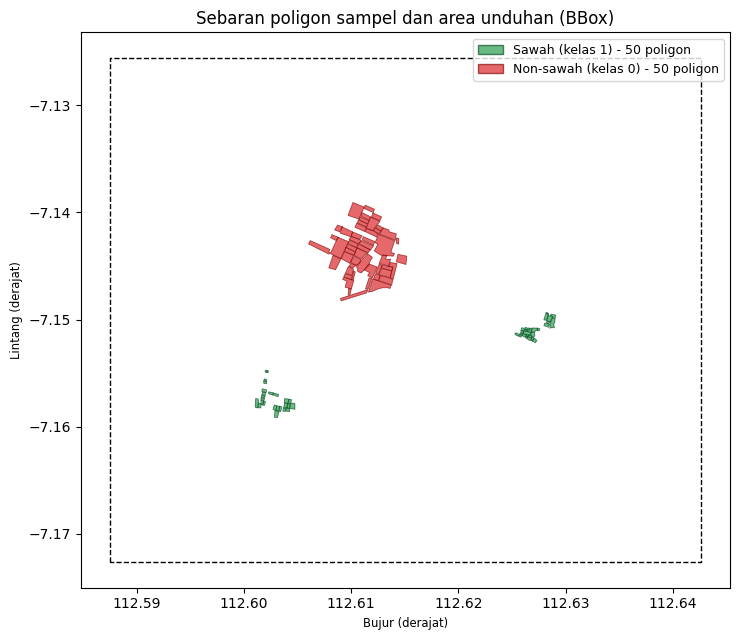

In [ ]:
from shapely.geometry import shape
from shapely.geometry import box as shp_box

fig, ax = plt.subplots(figsize=(9, 6.5))
gpd.GeoSeries([shape(g) for g in geoms_non]).plot(
    ax=ax, facecolor="#d7191c", edgecolor="#7f0000", alpha=0.65, linewidth=0.6)
gpd.GeoSeries([shape(g) for g in geoms_sawah]).plot(
    ax=ax, facecolor="#1a9641", edgecolor="#00441b", alpha=0.65, linewidth=0.6)
gpd.GeoSeries([shp_box(*BBOX)]).boundary.plot(ax=ax, color="k", linestyle="--", linewidth=1)

ax.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, fc="#1a9641", ec="#00441b", alpha=0.65,
                  label=f"Sawah (kelas 1) - {len(geoms_sawah)} poligon"),
    plt.Rectangle((0, 0), 1, 1, fc="#d7191c", ec="#7f0000", alpha=0.65,
                  label=f"Non-sawah (kelas 0) - {len(geoms_non)} poligon"),
], loc="upper right", fontsize=9)
ax.set_title("Sebaran poligon sampel dan area unduhan (BBox)")
ax.set_xlabel("Bujur (derajat)")
ax.set_ylabel("Lintang (derajat)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 3. Mengunduh Sentinel-2A (GeoTIFF) dari Copernicus

Pengunduhan memakai **Sentinel Hub API** di Copernicus Data Space dalam tiga tahap:

1. **`get_token`**: meminta token akses OAuth dengan Client ID dan Secret.
2. **`search_scenes`**: mencari scene Sentinel-2 L2A di atas `BBOX` pada rentang tanggal tertentu. Scene difilter berdasarkan satelit (`S2A`) dan tutupan awan, lalu diurutkan dari yang paling bersih.
3. **`download_scene`**: mengunduh area `BBOX` dari scene terpilih lewat *Process API* dengan ketentuan:
   - proyeksi **UTM** (zona dihitung otomatis dengan `utm_epsg`), resolusi **10 m**
   - **6 band reflektansi**: B02 (biru), B03 (hijau), B04 (merah), B08 (NIR), B11 (SWIR-1), B12 (SWIR-2)
   - piksel **awan, bayangan awan, cirrus, dan salju dibuang** memakai band **SCL** (*Scene Classification Layer*) lewat *evalscript*. Kelas SCL yang dibuang: 0, 1, 3, 8, 9, 10, 11.

Fungsi `fetch_sentinel2a` mencoba hingga `MAX_TRIES` scene terbaik, lalu memakai scene yang fraksi piksel validnya mencapai `MIN_VALID` (atau yang terbaik bila tidak ada yang mencapai). Hasilnya disimpan sebagai `sentinel2a_aoi.tif` beserta catatan metadata `sentinel2a_aoi_info.txt`.

Bila `sentinel2a_aoi.tif` sudah ada, langkah unduh **dilewati otomatis**. Kamu juga bisa menaruh GeoTIFF dari Copernicus Browser secara manual, asalkan urutan bandnya sama.

In [ ]:
# Kredensial hanya diminta jika citra belum pernah diunduh.
# Isi lewat environment variable CDSE_CLIENT_ID / CDSE_CLIENT_SECRET, atau ketik saat diminta.
if TIF_IN.exists():
    CLIENT_ID = CLIENT_SECRET = None
else:
    CLIENT_ID = os.environ.get("CDSE_CLIENT_ID") or input("CDSE Client ID: ").strip()
    CLIENT_SECRET = os.environ.get("CDSE_CLIENT_SECRET") or getpass.getpass("CDSE Client Secret: ").strip()

In [ ]:
def get_token():
    r = requests.post(TOKEN_URL, data={
        "grant_type": "client_credentials",
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET,
    }, timeout=60)
    if r.status_code != 200:
        raise RuntimeError(f"Gagal mengambil token ({r.status_code}): {r.text[:300]}\n"
                           "Cek CLIENT_ID dan CLIENT_SECRET (dashboard Sentinel Hub).")
    return r.json()["access_token"]


def search_scenes(token):
    body = {
        "collections": ["sentinel-2-l2a"],
        "datetime": f"{START_DATE}T00:00:00Z/{END_DATE}T23:59:59Z",
        "bbox": list(BBOX),
        "limit": 100,
    }
    headers = {"Authorization": f"Bearer {token}"}
    feats = []
    while True:
        r = requests.post(CATALOG_URL, json=body, headers=headers, timeout=120)
        if r.status_code != 200:
            raise RuntimeError(f"Pencarian katalog gagal ({r.status_code}): {r.text[:300]}")
        js = r.json()
        feats += js.get("features", [])
        nxt = js.get("context", {}).get("next")
        if not nxt:
            break
        body["next"] = nxt

    cand = []
    for it in feats:
        p = it.get("properties", {})
        cc = p.get("eo:cloud_cover")
        if cc is None or cc > MAX_CLOUD:
            continue
        if PLATFORM_PREFIX and not it["id"].upper().startswith(PLATFORM_PREFIX):
            continue
        cand.append((cc, p["datetime"], it["id"]))
    cand.sort()   # urut dari awan paling sedikit
    log(f"Scene ditemukan: {len(feats)} | lolos filter ({PLATFORM_PREFIX or 'semua'}, "
        f"awan <= {MAX_CLOUD}%): {len(cand)}")
    return cand


def utm_epsg(lon, lat):
    # Kode EPSG zona UTM (326xx = utara, 327xx = selatan)
    return (32700 if lat < 0 else 32600) + int((lon + 180) // 6) + 1


def build_evalscript():
    # Evalscript dijalankan di server Copernicus: mengembalikan 6 band,
    # dan 0 untuk piksel tanpa data / awan / bayangan / cirrus / salju (kelas SCL).
    mask = " || [0,1,3,8,9,10,11].indexOf(s.SCL) >= 0" if MASK_CLOUD else ""
    return ('//VERSION=3\n'
            'function setup() {\n'
            '  return {\n'
            '    input: [{bands: ["B02","B03","B04","B08","B11","B12","SCL","dataMask"]}],\n'
            '    output: {bands: 6, sampleType: "FLOAT32"}\n'
            '  };\n'
            '}\n'
            'function evaluatePixel(s) {\n'
            f'  var bad = (s.dataMask == 0){mask};\n'
            '  if (bad) return [0,0,0,0,0,0];\n'
            '  return [s.B02, s.B03, s.B04, s.B08, s.B11, s.B12];\n'
            '}\n')

In [ ]:
def download_scene(token, when):
    """Unduh area sampel dari satu scene: UTM, 10 m, 6 band reflektansi (float32)."""
    epsg = utm_epsg((BBOX[0] + BBOX[2]) / 2, (BBOX[1] + BBOX[3]) / 2)
    minx, miny, maxx, maxy = transform_bounds("EPSG:4326", f"EPSG:{epsg}", *BBOX)
    # Bulatkan ke kelipatan 10 m agar selaras dengan grid piksel Sentinel-2
    minx, miny = math.floor(minx / 10) * 10, math.floor(miny / 10) * 10
    maxx, maxy = math.ceil(maxx / 10) * 10, math.ceil(maxy / 10) * 10
    w, h = (maxx - minx) // 10, (maxy - miny) // 10
    if w > 2500 or h > 2500:
        raise RuntimeError(f"Area terlalu besar ({w}x{h} piksel, maks 2500). "
                           "Kecilkan BUFFER_M.")

    t = dt.datetime.fromisoformat(when.replace("Z", "+00:00")).astimezone(dt.timezone.utc)
    fmt = "%Y-%m-%dT%H:%M:%SZ"
    body = {
        "input": {
            "bounds": {
                "bbox": [minx, miny, maxx, maxy],
                "properties": {"crs": f"http://www.opengis.net/def/crs/EPSG/0/{epsg}"},
            },
            "data": [{
                "type": "sentinel-2-l2a",
                "dataFilter": {
                    "timeRange": {"from": (t - dt.timedelta(minutes=1)).strftime(fmt),
                                  "to": (t + dt.timedelta(minutes=1)).strftime(fmt)},
                    "mosaickingOrder": "leastCC",
                },
            }],
        },
        "output": {
            "resx": 10, "resy": 10,
            "responses": [{"identifier": "default", "format": {"type": "image/tiff"}}],
        },
        "evalscript": build_evalscript(),
    }
    r = requests.post(PROCESS_URL, json=body, timeout=300, headers={
        "Authorization": f"Bearer {token}", "Accept": "image/tiff"})
    if r.status_code != 200:
        raise RuntimeError(f"Unduhan gagal ({r.status_code}): {r.text[:400]}")
    return r.content, epsg


def valid_fraction(tif_bytes):
    # Fraksi piksel yang berisi data (bukan 0 / NaN) di area unduhan
    from rasterio.io import MemoryFile
    with MemoryFile(tif_bytes) as mf, mf.open() as src:
        arr = src.read()
    return float((np.any(arr != 0, axis=0) & np.isfinite(arr).all(axis=0)).mean())


def fetch_sentinel2a():
    token = get_token()
    cand = search_scenes(token)
    if not cand:
        raise RuntimeError(
            f"Tidak ada scene {PLATFORM_PREFIX or ''} dengan awan <= {MAX_CLOUD}% pada "
            f"{START_DATE} s/d {END_DATE}. Perlebar START_DATE/END_DATE atau naikkan "
            "MAX_CLOUD (atau PLATFORM_PREFIX=None untuk semua satelit).")

    best = None
    for cc, when, sid in cand[:MAX_TRIES]:
        data, epsg = download_scene(token, when)
        frac = valid_fraction(data)
        log(f"  {sid[:40]}... | {when} | awan tile {cc:.1f}% | piksel valid {frac:.1%}")
        if best is None or frac > best["frac"]:
            best = dict(frac=frac, data=data, when=when, sid=sid, cc=cc, epsg=epsg)
        if frac >= MIN_VALID:
            break

    TIF_IN.write_bytes(best["data"])
    INFO_TXT.write_text(
        f"Scene    : {best['sid']}\nAkuisisi : {best['when']}\n"
        f"Awan tile: {best['cc']:.1f}%\nPiksel valid di AOI: {best['frac']:.1%}\n"
        f"CRS      : EPSG:{best['epsg']}\nResolusi : 10 m\n"
        f"Band     : {', '.join(BAND_NAMES)} (reflektansi 0-1)\n"
        f"Masking awan (SCL): {MASK_CLOUD}\n", encoding="utf-8")
    log(f"Scene dipakai: {best['sid']} ({best['when']}), valid {best['frac']:.1%}")
    log("Tersimpan:", TIF_IN, "dan", INFO_TXT)


if TIF_IN.exists():
    log(f"{TIF_IN.name} sudah ada -> langkah unduh dilewati.")
else:
    fetch_sentinel2a()

## 4. Membaca citra GeoTIFF

Citra dibaca dengan `rasterio` menjadi array `stack` berukuran `(6 band, tinggi, lebar)`. Piksel yang seluruh bandnya bernilai 0 (hasil masking awan di server) atau tidak valid diubah menjadi **NaN** supaya tidak ikut dilatih maupun diklasifikasikan.

Dictionary `B` memetakan nama band ke arraynya (`B["B04"]` = band merah, dan seterusnya) agar rumus indeks mudah dibaca.

In [ ]:
with rasterio.open(TIF_IN) as src:
    stack = src.read().astype("float32")
    crs, transform = src.crs, src.transform
if stack.shape[0] != len(BAND_NAMES):
    raise RuntimeError(f"TIF punya {stack.shape[0]} band, harus {len(BAND_NAMES)} "
                       f"({', '.join(BAND_NAMES)}).")
invalid = np.all(stack == 0, axis=0) | ~np.isfinite(stack).all(axis=0)
stack[:, invalid] = np.nan
H, W = stack.shape[1:]
log(f"Ukuran citra: {W} x {H} piksel | CRS: {crs} | piksel tanpa data: {invalid.mean():.1%}")
B = dict(zip(BAND_NAMES, stack))

## 5. Fitur: band spektral + indeks

Selain 6 band asli, ditambahkan **4 indeks spektral** yang membantu memisahkan sawah dari non-sawah. Total ada **10 fitur** per piksel.

| Fitur | Rumus | Kegunaan |
|---|---|---|
| **NDVI** | `(B08 - B04) / (B08 + B04)` | Kehijauan/kerapatan vegetasi. Padi yang sedang tumbuh bernilai tinggi. |
| **NDWI** | `(B03 - B08) / (B03 + B08)` | Kandungan air permukaan. Sawah yang digenangi memberi nilai lebih tinggi. |
| **NDBI** | `(B11 - B08) / (B11 + B08)` | Area terbangun. Permukiman dan bangunan bernilai tinggi. |
| **EVI** | `2.5 * (B08 - B04) / (B08 + 6*B04 - 7.5*B02 + 1)` | Vegetasi yang lebih tahan terhadap efek atmosfer dan saturasi dibanding NDVI. |

Suku `1e-10` pada fungsi `nd()` mencegah pembagian dengan nol.

In [ ]:
def nd(a, b):
    # Normalized difference: (a - b) / (a + b)
    return (a - b) / (a + b + 1e-10)

ndvi = nd(B["B08"], B["B04"])
ndwi = nd(B["B03"], B["B08"])
ndbi = nd(B["B11"], B["B08"])
evi = 2.5 * (B["B08"] - B["B04"]) / (B["B08"] + 6 * B["B04"] - 7.5 * B["B02"] + 1)

feats = np.concatenate([stack, np.stack([ndvi, ndwi, ndbi, evi])]).astype("float32")
FEATURE_NAMES = BAND_NAMES + ["NDVI", "NDWI", "NDBI", "EVI"]
F = feats.shape[0]

## 6. Rasterisasi poligon sampel

Poligon sampel (koordinat lon/lat) diubah ke sistem koordinat citra (`transform_geom`), lalu **dirasterisasi** menjadi grid yang sama dengan citra. Setiap piksel di dalam poligon diberi **ID poligon**, sedangkan piksel di luar poligon bernilai 0.

Hanya piksel yang berada di dalam poligon **dan** memiliki data valid (bebas awan) yang dipakai sebagai data berlabel (`labeled`). Notebook juga melaporkan jumlah poligon dan piksel yang terpakai per kelas, serta memberi peringatan bila ada poligon yang seluruhnya tertutup awan atau berada di luar citra.

In [ ]:
poly_label, shapes, pid = {}, [], 0
for geoms, kelas in ((geoms_non, 0), (geoms_sawah, 1)):
    for g in geoms:
        pid += 1
        poly_label[pid] = kelas
        shapes.append((transform_geom("EPSG:4326", crs, g), pid))

poly_raster = features.rasterize(shapes, out_shape=(H, W), transform=transform,
                                 fill=0, dtype="int32")
labeled = (poly_raster > 0) & np.isfinite(feats).all(axis=0)
present = np.unique(poly_raster[labeled])

for k, nama in ((0, "non-sawah"), (1, "sawah")):
    ids = [p for p in present if poly_label[p] == k]
    npx = int(np.isin(poly_raster, ids).sum())
    log(f"Kelas {k} ({nama}): {len(ids)} poligon terpakai, {npx} piksel bebas awan")
if len(present) < len(poly_label):
    log(f"PERINGATAN: {len(poly_label) - len(present)} poligon tidak punya piksel valid "
        "(tertutup awan atau di luar citra).")

## 7. Pembagian data training dan testing per poligon

Pembagian dilakukan **per poligon, bukan per piksel**. Piksel yang bertetangga di dalam satu poligon sangat mirip. Jika dipisah per piksel, sebagian piksel poligon yang sama akan masuk training dan sebagian lagi testing, sehingga akurasi tampak terlalu tinggi (*spatial data leakage*).

Dengan pembagian per poligon, **70% poligon** tiap kelas menjadi data latih dan **30%** sisanya menjadi data uji yang benar-benar belum pernah dilihat model.

In [ ]:
rng = np.random.default_rng(SEED)
train_ids = []
for k in (0, 1):
    ids = [p for p in present if poly_label[p] == k]
    rng.shuffle(ids)
    train_ids += ids[:max(1, int(round(len(ids) * TRAIN_FRAC)))]

m_train = labeled & np.isin(poly_raster, train_ids)
m_test = labeled & ~m_train
lab_map = np.zeros(poly_raster.max() + 1, dtype="uint8")
for p, k in poly_label.items():
    lab_map[p] = k

X_train, y_train = feats[:, m_train].T, lab_map[poly_raster[m_train]]
X_test, y_test = feats[:, m_test].T, lab_map[poly_raster[m_test]]
log(f"Poligon training: {len(train_ids)} | testing: {len(present) - len(train_ids)}")
log(f"Piksel training: {len(y_train)} | testing: {len(y_test)}")

## 8. Melatih dan mengevaluasi model

**Random Forest** adalah kumpulan banyak pohon keputusan (di sini `N_TREES = 200`) yang masing-masing dilatih pada sampel data berbeda, lalu hasilnya digabung lewat *voting*. Metode ini tahan terhadap *overfitting*, tidak memerlukan normalisasi fitur, dan memberi ukuran **kepentingan fitur**.

Evaluasi memakai data uji (poligon yang tidak dipakai saat training):

- **Confusion matrix**: baris = kelas aktual, kolom = kelas prediksi (urutan 0 = non-sawah, 1 = sawah).
- **Overall Accuracy**: proporsi piksel uji yang diprediksi benar.
- **Kappa**: kesepakatan prediksi dan aktual setelah mengoreksi kebetulan. Nilai mendekati 1 berarti sangat baik.
- **Precision / Recall / F1** per kelas, dan **kepentingan fitur** untuk melihat band atau indeks yang paling berperan.

In [ ]:
rf = RandomForestClassifier(n_estimators=N_TREES, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
pred_test = rf.predict(X_test)

log("\nConfusion matrix (baris=aktual, kolom=prediksi; urutan 0=non-sawah, 1=sawah):")
log(confusion_matrix(y_test, pred_test, labels=[0, 1]))
log(f"Overall Accuracy : {accuracy_score(y_test, pred_test):.4f}")
log(f"Kappa            : {cohen_kappa_score(y_test, pred_test):.4f}")
log(classification_report(y_test, pred_test, labels=[0, 1],
                          target_names=["non-sawah", "sawah"], digits=3))
log("Kepentingan fitur:")
for n, v in sorted(zip(FEATURE_NAMES, rf.feature_importances_), key=lambda x: -x[1]):
    log(f"  {n:5s} {v:.3f}")

## 9. Klasifikasi seluruh citra

Setelah akurasi diukur dari data uji, **model akhir dilatih ulang dengan semua sampel** (training + testing) agar memanfaatkan seluruh informasi yang tersedia. Model akhir ini kemudian memprediksi **setiap piksel** pada citra.

Piksel tanpa data (tertutup awan, bayangan awan, dan sebagainya) diberi nilai `255` sebagai *nodata*, sehingga tidak diklasifikasikan. Karena citra berproyeksi UTM (satuan meter), luas tiap kelas dapat dihitung dari jumlah piksel dikalikan luas satu piksel (10 m x 10 m = 100 m²) dan dikonversi ke hektare.

In [ ]:
# Model akhir dilatih ulang dengan SEMUA sampel; akurasi di atas tetap dari data uji.
rf_final = RandomForestClassifier(n_estimators=N_TREES, random_state=SEED, n_jobs=-1)
rf_final.fit(feats[:, labeled].T, lab_map[poly_raster[labeled]])

flat = feats.reshape(F, -1).T
ok = np.isfinite(flat).all(axis=1)
pred = np.full(flat.shape[0], 255, dtype="uint8")    # 255 = nodata
pred[ok] = rf_final.predict(flat[ok]).astype("uint8")
classified = pred.reshape(H, W)

if crs.is_projected:
    px_area = abs(transform.a * transform.e)
    log(f"\nLuas sawah    : {(classified == 1).sum() * px_area / 10000:.1f} ha")
    log(f"Luas non-sawah: {(classified == 0).sum() * px_area / 10000:.1f} ha")

## 10. Menyimpan GeoTIFF, peta, dan ringkasan

Tiga keluaran disimpan:

1. **`klasifikasi_sawah_s2a.tif`**: GeoTIFF 1 band (`uint8`, kompresi LZW) dengan nilai 1 = sawah, 0 = non-sawah, 255 = nodata. Peta warna (*colormap*) sudah ditanam, sehingga langsung berwarna di QGIS atau ArcGIS. Ini **hasil utama tugas**.
2. **`peta_klasifikasi.png`**: perbandingan citra RGB asli (kiri) dan hasil klasifikasi (kanan).
3. **`hasil_evaluasi.txt`**: seluruh catatan `log` (jumlah sampel, confusion matrix, akurasi, kappa, luas).

Citra RGB dibuat dari band B04 (merah), B03 (hijau), dan B02 (biru), lalu diregangkan kontrasnya dengan persentil 2-98% agar tampak jelas.

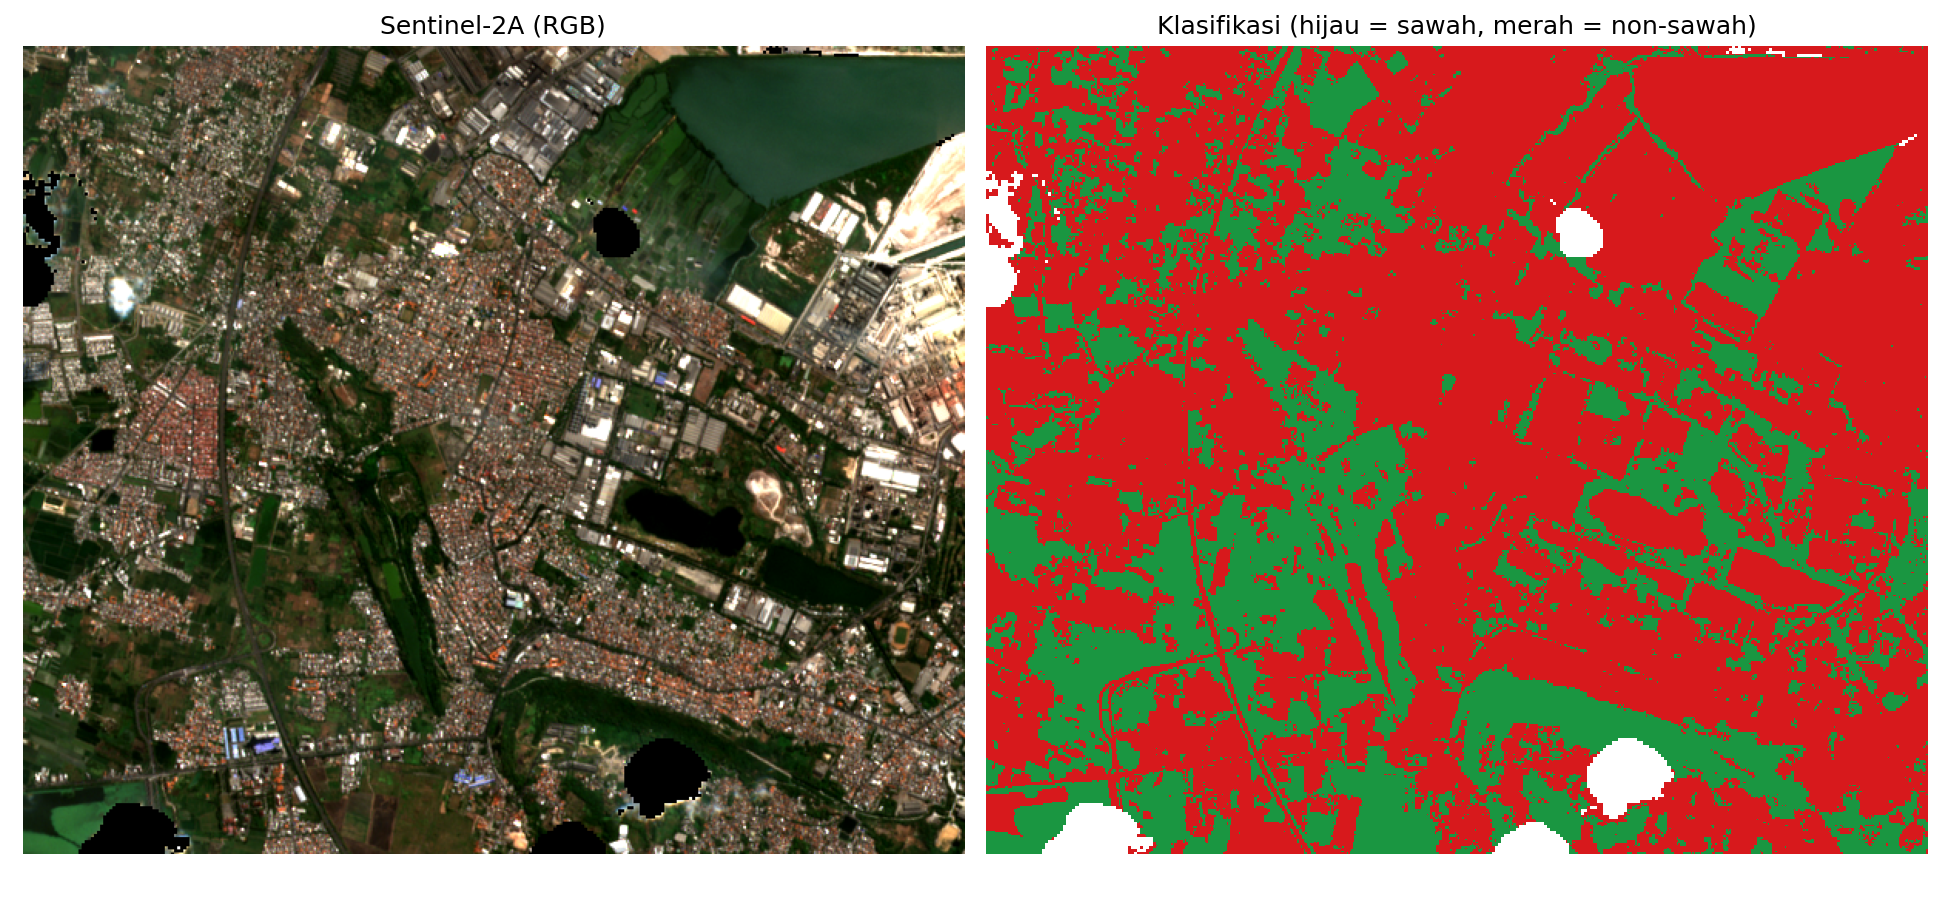

In [ ]:
with rasterio.open(OUT_TIF, "w", driver="GTiff", height=H, width=W, count=1,
                   dtype="uint8", crs=crs, transform=transform,
                   nodata=255, compress="lzw") as dst:
    dst.write(classified, 1)
    dst.set_band_description(1, "kelas (1=sawah, 0=non-sawah)")
    dst.write_colormap(1, {0: (215, 25, 28, 255), 1: (26, 150, 65, 255),
                           255: (0, 0, 0, 0)})

# Komposit RGB alami dengan peregangan kontras persentil 2-98%
rgb = np.dstack([B["B04"], B["B03"], B["B02"]])
lo, hi = np.nanpercentile(rgb, 2), np.nanpercentile(rgb, 98)
rgb = np.nan_to_num(np.clip((rgb - lo) / (hi - lo + 1e-10), 0, 1))

fig, ax = plt.subplots(1, 2, figsize=(13, 6))
ax[0].imshow(rgb)
ax[0].set_title("Sentinel-2A (RGB)")
ax[1].imshow(np.ma.masked_equal(classified, 255),
             cmap=ListedColormap(["#d7191c", "#1a9641"]), vmin=0, vmax=1,
             interpolation="nearest")
ax[1].set_title("Klasifikasi (hijau = sawah, merah = non-sawah)")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150)
plt.show()

OUT_TXT.write_text("\n".join(LOG), encoding="utf-8")
log("\nSelesai. Output:")
log("  GeoTIFF  :", OUT_TIF)
log("  Pratinjau:", OUT_PNG)
log("  Evaluasi :", OUT_TXT)

### Cara membaca peta hasil

- **Kiri**: citra Sentinel-2A dalam warna alami (RGB). Area **hitam** adalah piksel yang dibuang karena awan atau bayangan awan (hasil masking SCL).
- **Kanan**: hasil klasifikasi. **Hijau** = sawah, **merah** = non-sawah. Area **putih** adalah *nodata*, yaitu piksel yang sama dengan area hitam di citra kiri sehingga tidak diklasifikasikan.
- Sawah (hijau) terkonsentrasi pada hamparan lahan terbuka bervegetasi atau tergenang, sedangkan permukiman dan kawasan industri yang padat terklasifikasi sebagai non-sawah (merah).

### Catatan dan keterbatasan

- Akurasi dihitung pada **piksel di dalam poligon uji**. Nilai ini menggambarkan kemampuan model pada tipe lahan yang diwakili sampel, bukan akurasi seluruh peta.
- Kelas **non-sawah** mencakup banyak jenis penutup (permukiman, industri, badan air, vegetasi non-padi), sedangkan sampelnya hanya 50 poligon. Piksel dengan karakteristik di luar sampel (misalnya tambak atau lahan kosong) bisa saja salah klasifikasi.
- Hasil bergantung pada **tanggal akuisisi**. Fase tanam padi (digenangi, vegetatif, panen) mengubah nilai NDVI dan NDWI, sehingga citra pada waktu berbeda dapat menghasilkan peta berbeda.
- Penambahan sampel di area yang sering salah dan penggunaan citra multi-temporal adalah cara umum untuk meningkatkan akurasi.